Symbolic Transfer Function H(s):
                                    1                                     
──────────────────────────────────────────────────────────────────────────
            3                2                   2                        
C₁⋅C₂⋅L⋅R₁⋅s  + C₁⋅C₂⋅R₁⋅R₂⋅s  + C₁⋅R₁⋅s + C₂⋅L⋅s  + C₂⋅R₁⋅s + C₂⋅R₂⋅s + 1


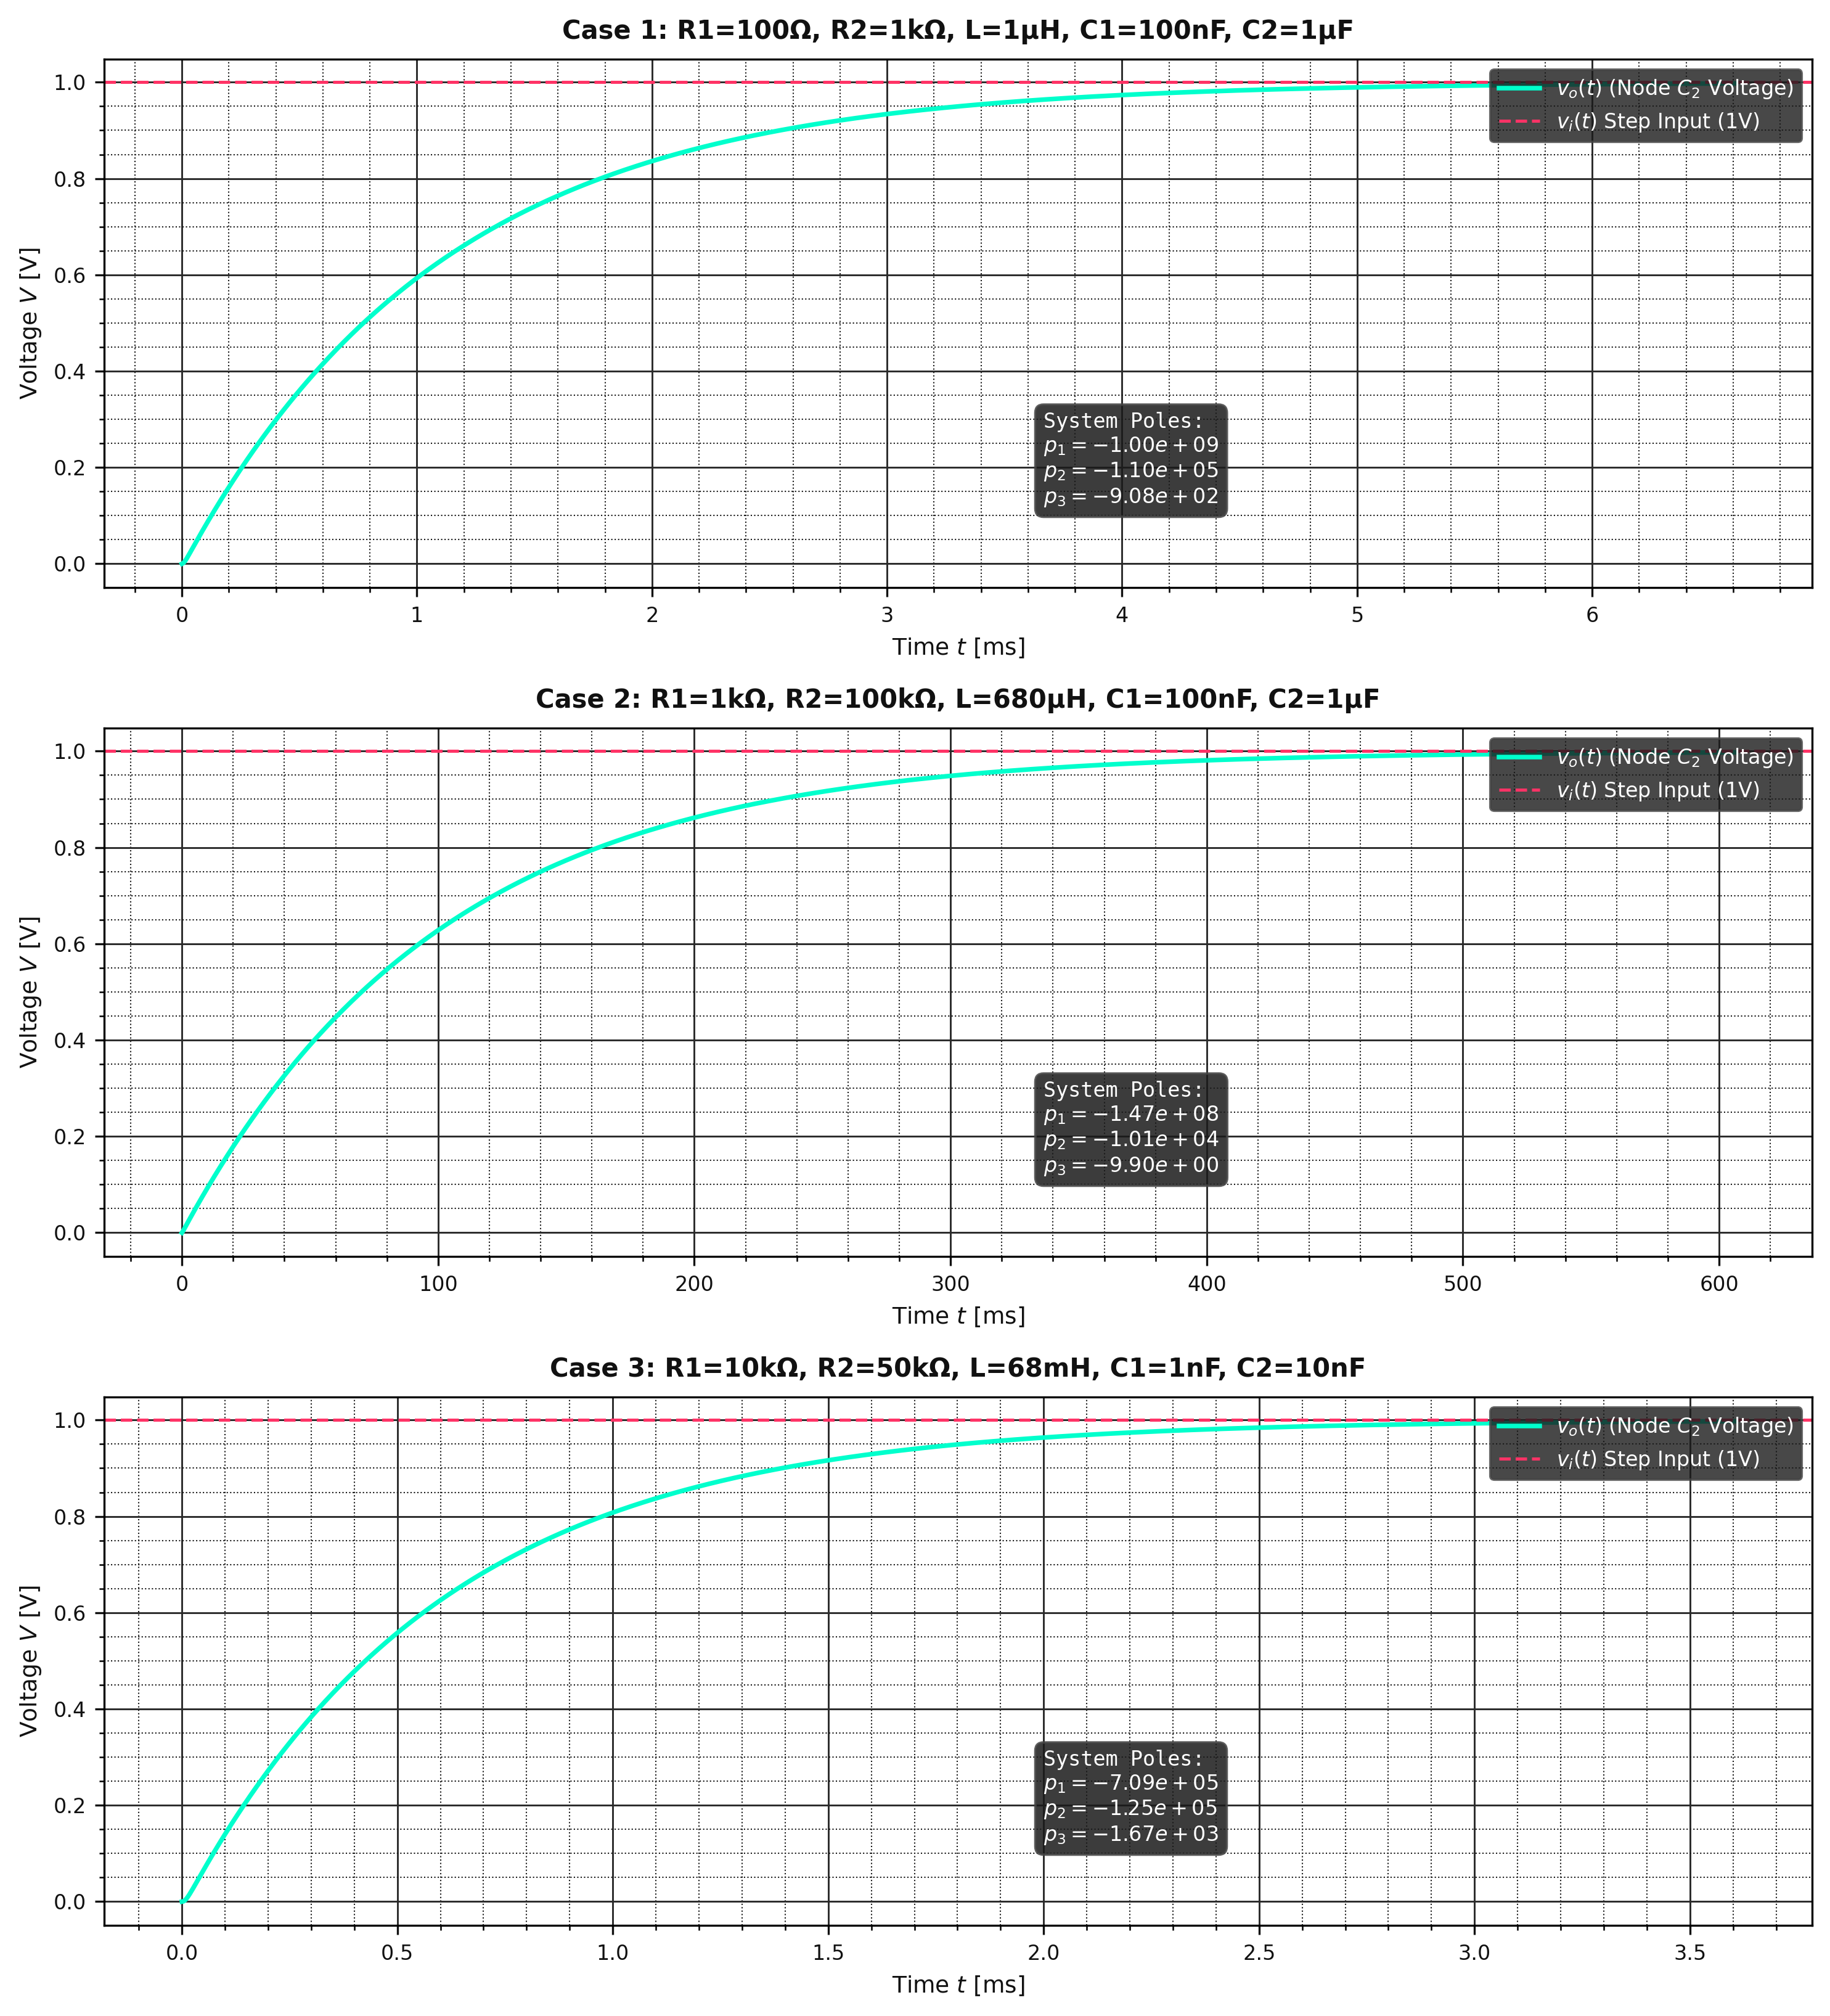

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import sympy as sp

# =====================================================================
# PART 1: Analytical Transfer Function & Pole Calculation via SymPy
# =====================================================================
s, R1, R2, L, C1, C2 = sp.symbols('s R1 R2 L C1 C2')
v1, v2, Vin = sp.symbols('v1 v2 Vin')

# Nodal Equations at Node 1 (v1) and Node 2 (v2 = Vo)
eq1 = sp.Eq((Vin - v1)/R1, s*C1*v1 + (v1 - v2)/(s*L + R2))
eq2 = sp.Eq((v1 - v2)/(s*L + R2), s*C2*v2)

# Solve for Transfer Function H(s) = V2(s) / Vin(s)
sol = sp.solve([eq1, eq2], (v1, v2))
H_s = sp.simplify(sol[v2] / Vin)

print("Symbolic Transfer Function H(s):")
sp.pprint(H_s)

# Defined component values for each test case
cases_vals = [
    {"R1": 100, "R2": 1000, "L": 1e-6, "C1": 100e-9, "C2": 1e-6},
    {"R1": 1000, "R2": 100000, "L": 680e-6, "C1": 100e-9, "C2": 1e-6},
    {"R1": 10000, "R2": 50000, "L": 68e-3, "C1": 1e-9, "C2": 10e-9}
]

# =====================================================================
# PART 2: Numerical State-Space Simulation & Plot Generation
# =====================================================================
cases_3rd = [
    (100, 1000, 1e-6, 100e-9, 1e-6, "Case 1: R1=100Ω, R2=1kΩ, L=1µH, C1=100nF, C2=1µF"),
    (1000, 100000, 680e-6, 100e-9, 1e-6, "Case 2: R1=1kΩ, R2=100kΩ, L=680µH, C1=100nF, C2=1µF"),
    (10000, 50000, 68e-3, 1e-9, 10e-9, "Case 3: R1=10kΩ, R2=50kΩ, L=68mH, C1=1nF, C2=10nF"),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 11), dpi=300)

for i, (R1_val, R2_val, L_val, C1_val, C2_val, title) in enumerate(cases_3rd):
    # State-Space Formulation: x = [v_C1, i_L, v_C2]^T
    A = np.array([
        [-1/(R1_val*C1_val), -1/C1_val, 0],
        [1/L_val, -R2_val/L_val, -1/L_val],
        [0, 1/C2_val, 0]
    ])
    B = np.array([[1/(R1_val*C1_val)], [0], [0]])
    C_mat = np.array([[0, 0, 1]])  # Output voltage across C2
    D = np.array([[0]])
    
    sys = signal.StateSpace(A, B, C_mat, D)
    poles = sys.poles
    
    # Calculate simulation time scale based on dominant pole
    min_real_pole = np.min(np.abs(np.real(poles)))
    t_max = 6 / min_real_pole if min_real_pole > 0 else 1e-3
    
    t = np.linspace(0, t_max, 1000)
    t_step, y_step = signal.step(sys, T=t)
    
    ax = axes[i]
    
    # Adaptive time unit formatting
    if t_max < 1e-3:
        tf, tu = 1e6, "µs"
    elif t_max < 1:
        tf, tu = 1e3, "ms"
    else:
        tf, tu = 1, "s"
        
    ax.grid(True, which='major', color='#2a2a2a', linestyle='-', linewidth=0.7)
    ax.grid(True, which='minor', color='#1a1a1a', linestyle=':', linewidth=0.5)
    ax.minorticks_on()
    
    # Plot Step Response
    ax.plot(t_step * tf, y_step, color='#00ffcc', linewidth=1.8, label=r'$v_o(t)$ (Node $C_2$ Voltage)')
    ax.axhline(1.0, color='#ff3366', linestyle='--', linewidth=1.2, label=r'$v_i(t)$ Step Input (1V)')
    
    # System Poles Readout Box
    pole_str = "\n".join([
        f"$p_{{{j+1}}} = {p.real:.2e} + {p.imag:.2e}j$" if abs(p.imag) > 1e-5 
        else f"$p_{{{j+1}}} = {p.real:.2e}$" 
        for j, p in enumerate(poles)
    ])
    
    props = dict(boxstyle='round,pad=0.4', facecolor='#1a1a1a', alpha=0.85, edgecolor='#444444')
    ax.text(0.55, 0.15, f"System Poles:\n{pole_str}", transform=ax.transAxes, fontsize=8,
            verticalalignment='bottom', bbox=props, color='#ffffff', family='monospace')
            
    ax.set_title(title, fontsize=10, fontweight='bold', color='#111111', pad=8)
    ax.set_xlabel(f'Time $t$ [{tu}]', fontsize=9, color='#111111')
    ax.set_ylabel('Voltage $V$ [V]', fontsize=9, color='#111111')
    ax.tick_params(colors='#111111', labelsize=8)
    ax.legend(loc='upper right', fontsize=8, facecolor='#1a1a1a', edgecolor='#444444', labelcolor='#ffffff')

plt.tight_layout()
plt.savefig("third_order_step_responses.png", dpi=300)
plt.show()

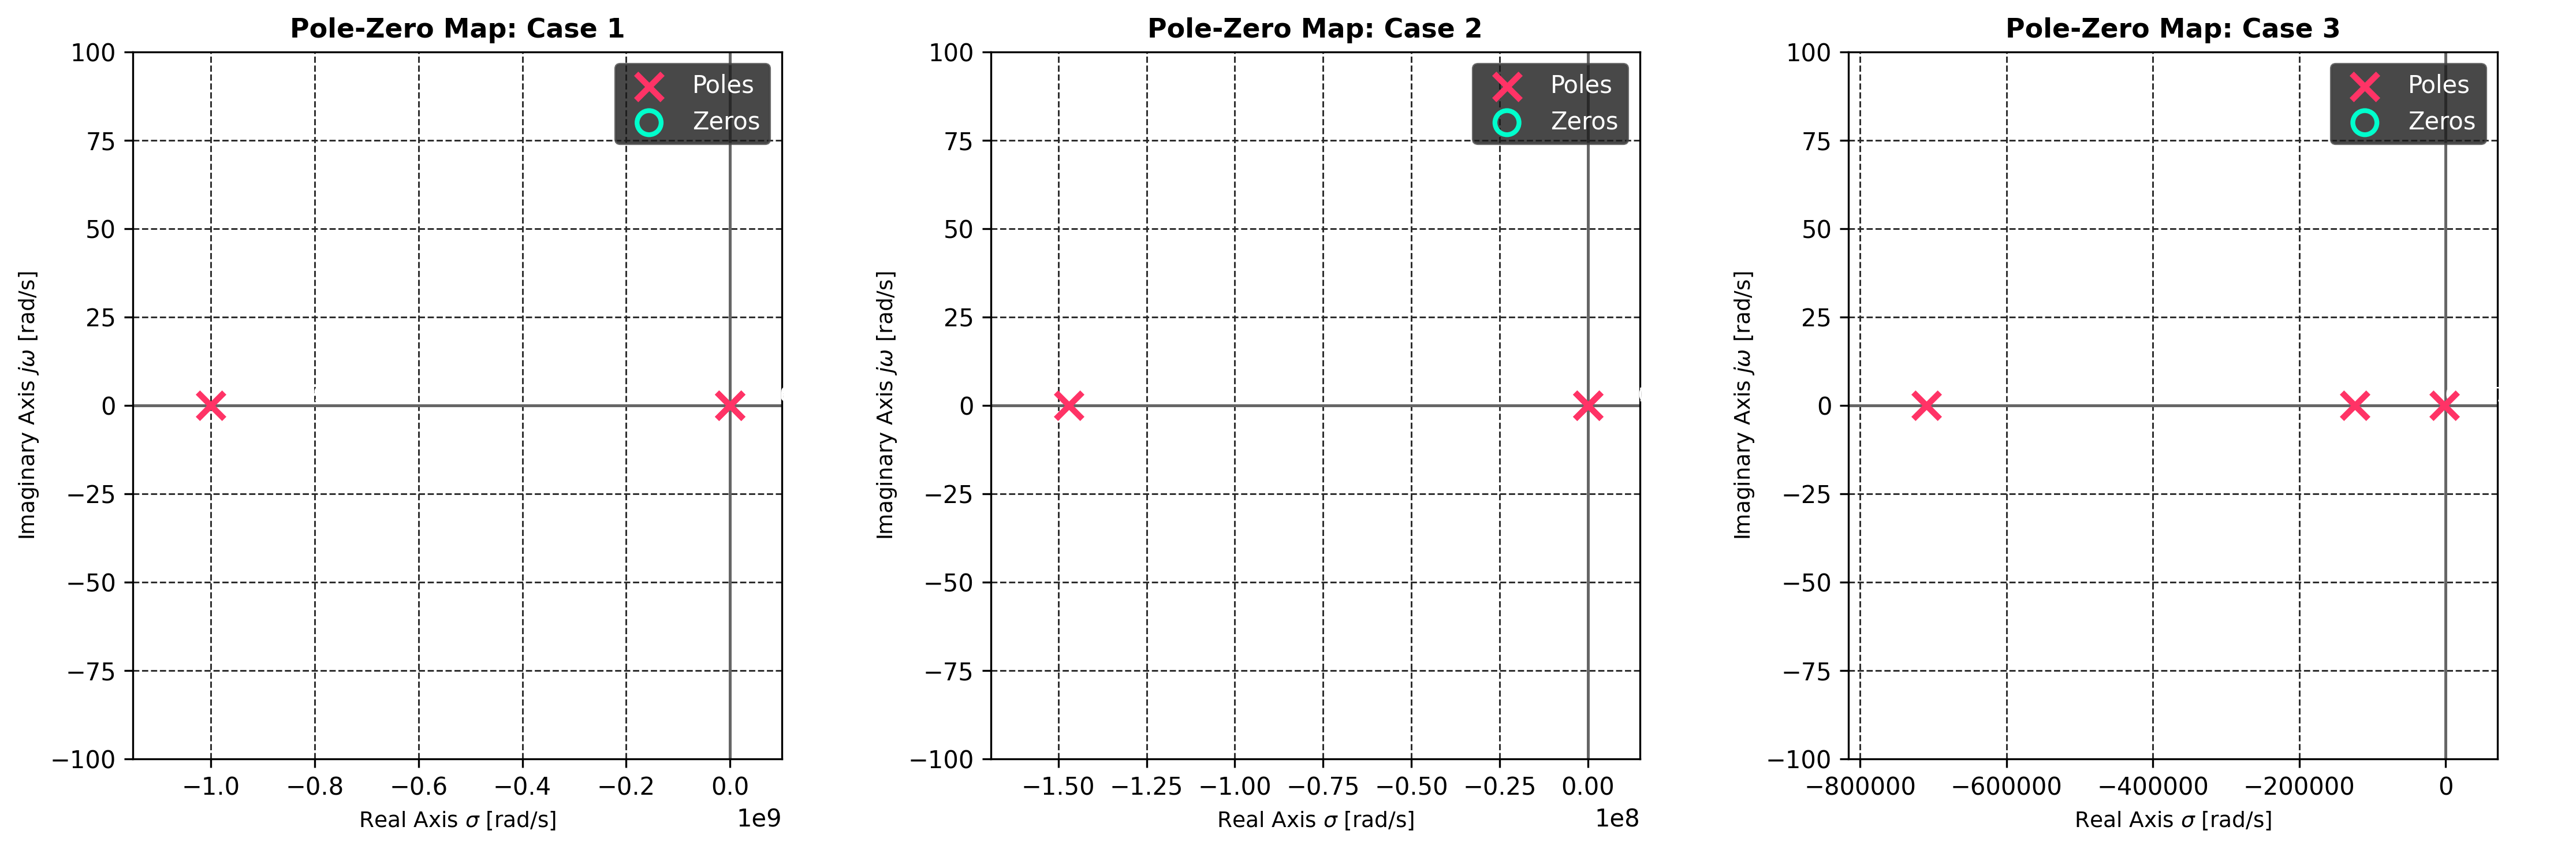

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# Set up figure styling for high-resolution output
plt.rcParams['font.family'] = 'sans-serif'
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

# Component parameter sets
cases = [
    {"R1": 100, "R2": 1000, "L": 1e-6, "C1": 100e-9, "C2": 1e-6, "title": "Case 1"},
    {"R1": 1000, "R2": 100000, "L": 680e-6, "C1": 100e-9, "C2": 1e-6, "title": "Case 2"},
    {"R1": 10000, "R2": 50000, "L": 68e-3, "C1": 1e-9, "C2": 10e-9, "title": "Case 3"}
]

for i, case in enumerate(cases):
    ax = axes[i]
    R1, R2, L, C1, C2 = case["R1"], case["R2"], case["L"], case["C1"], case["C2"]
    
    # State-Space Matrices
    A = np.array([
        [-1/(R1*C1), -1/C1, 0],
        [1/L, -R2/L, -1/L],
        [0, 1/C2, 0]
    ])
    B = np.array([[1/(R1*C1)], [0], [0]])
    C_mat = np.array([[0, 0, 1]])
    D = np.array([[0]])
    
    # Convert state space to transfer function to extract zeros and poles
    sys = signal.StateSpace(A, B, C_mat, D)
    tf = sys.to_tf()
    
    poles = tf.poles
    zeros = tf.zeros  # Note: Transfer function numerator has no finite zeros
    
    # Formatting graph background
    ax.grid(True, which='both', color='#2a2a2a', linestyle='--', linewidth=0.7)
    
    # Draw s-plane Real (σ) and Imaginary (jω) axes
    ax.axhline(0, color='#666666', linewidth=1.2)
    ax.axvline(0, color='#666666', linewidth=1.2)
    
    # Plot Poles ('x')
    ax.scatter(poles.real, poles.imag, color='#ff3366', marker='x', s=120, linewidths=2.5, label='Poles', zorder=5)
    
    # Plot Zeros ('o') if any exist
    if len(zeros) > 0:
        ax.scatter(zeros.real, zeros.imag, color='#00ffcc', marker='o', s=100, facecolors='none', edgecolors='#00ffcc', linewidths=2, label='Zeros', zorder=5)

    # Label pole values on plot
    for p in poles:
        ax.annotate(f'  {p.real:.2e}', (p.real, p.imag), color='#ffffff', fontsize=8, verticalalignment='bottom')

    ax.set_title(f"Pole-Zero Map: {case['title']}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Real Axis $\sigma$ [rad/s]', fontsize=9)
    ax.set_ylabel('Imaginary Axis $j\omega$ [rad/s]', fontsize=9)
    ax.legend(loc='upper right', facecolor='#1a1a1a', edgecolor='#444444', labelcolor='#ffffff')
    
    # Set symmetry limits around axes
    max_real = max(abs(poles.real))
    ax.set_xlim(-max_real * 1.15, max_real * 0.1)
    ax.set_ylim(-100, 100)

plt.tight_layout()
plt.savefig("third_order_pole_zero_map.png", dpi=300)
plt.show()

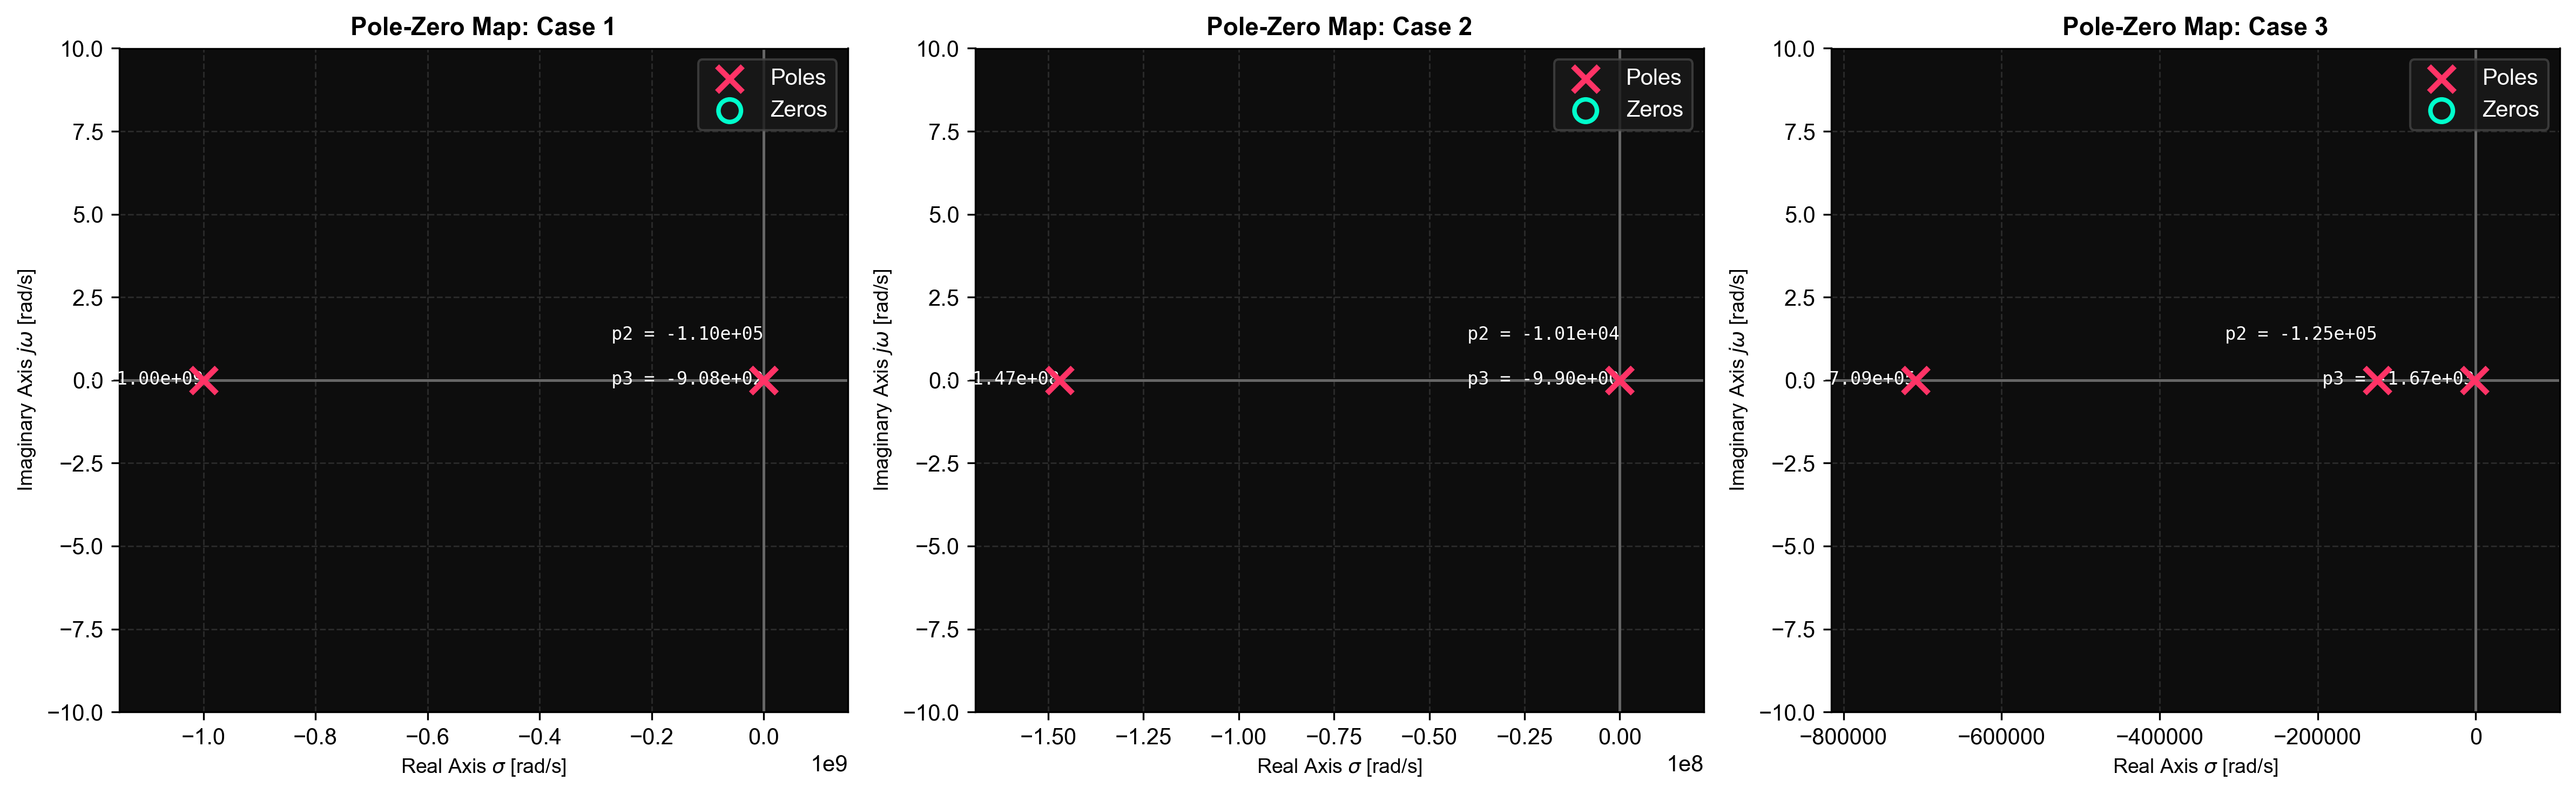

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# Configure plot styling
plt.rcParams['font.sans-serif'] = 'Arial'
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=300)

# Defined component values for the three cases
cases = [
    {"R1": 100, "R2": 1000, "L": 1e-6, "C1": 100e-9, "C2": 1e-6, "title": "Case 1"},
    {"R1": 1000, "R2": 100000, "L": 680e-6, "C1": 100e-9, "C2": 1e-6, "title": "Case 2"},
    {"R1": 10000, "R2": 50000, "L": 68e-3, "C1": 1e-9, "C2": 10e-9, "title": "Case 3"}
]

for i, case in enumerate(cases):
    ax = axes[i]
    R1, R2, L, C1, C2 = case["R1"], case["R2"], case["L"], case["C1"], case["C2"]
    
    # Formulate State-Space Matrices
    A = np.array([
        [-1/(R1*C1), -1/C1, 0],
        [1/L, -R2/L, -1/L],
        [0, 1/C2, 0]
    ])
    B = np.array([[1/(R1*C1)], [0], [0]])
    C_mat = np.array([[0, 0, 1]])
    D = np.array([[0]])
    
    # Extract Transfer Function, Poles, and Zeros
    sys = signal.StateSpace(A, B, C_mat, D)
    tf = sys.to_tf()
    
    poles = tf.poles
    zeros = tf.zeros  # Note: This network has all finite zeros at infinity

    # Axis Styling
    ax.set_facecolor('#0d0d0d')
    ax.grid(True, which='both', color='#2a2a2a', linestyle='--', linewidth=0.7)
    
    # Draw s-plane Axes (Real σ and Imaginary jω)
    ax.axhline(0, color='#666666', linewidth=1.2)
    ax.axvline(0, color='#666666', linewidth=1.2)
    
    # Plot Poles ('x' markers)
    ax.scatter(poles.real, poles.imag, color='#ff3366', marker='x', s=130, linewidths=2.5, label='Poles', zorder=5)
    
    # Plot Zeros ('o' markers) if any exist
    if len(zeros) > 0:
        ax.scatter(zeros.real, zeros.imag, color='#00ffcc', marker='o', s=100, facecolors='none', edgecolors='#00ffcc', linewidths=2, label='Zeros', zorder=5)

    # Annotate pole numerical values near the markers
    for idx, p in enumerate(poles):
        offset = (idx % 2) * 20 - 10
        ax.annotate(f' p{idx+1} = {p.real:.2e}', 
                    (p.real, p.imag), 
                    color='#ffffff', 
                    fontsize=8, 
                    xytext=(0, 8 + offset),
                    textcoords='offset points',
                    ha='right',
                    family='monospace')

    ax.set_title(f"Pole-Zero Map: {case['title']}", fontsize=11, fontweight='bold')
    ax.set_xlabel(r'Real Axis $\sigma$ [rad/s]', fontsize=9)
    ax.set_ylabel(r'Imaginary Axis $j\omega$ [rad/s]', fontsize=9)
    ax.legend(loc='upper right', facecolor='#1a1a1a', edgecolor='#444444', labelcolor='#ffffff')
    
    # Scale axes symmetrically around the roots
    max_real = max(abs(poles.real))
    ax.set_xlim(-max_real * 1.15, max_real * 0.15)
    ax.set_ylim(-10, 10)  # Magnified view around real axis since poles are purely real

plt.tight_layout()
plt.savefig("third_order_pole_zero_map.png", dpi=300)
plt.show()